<a href="https://colab.research.google.com/github/Mahian-Hoq/Varsity_Work/blob/main/lab_evaluation_DS_424.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
from tensorflow.keras.utils import to_categorical

In [ ]:
(x_train, y_train), (x_test , y_test) = keras.datasets.fashion_mnist.load_data()

In [ ]:
x_train = x_train / 255.0
x_test = x_test /255.0

In [ ]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [ ]:
model = keras.models.Sequential([
    layers.Input(shape = (28,28), name = "Input_Layer"),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(60, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6635 - loss: 0.9336 - val_accuracy: 0.8405 - val_loss: 0.4307
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8292 - loss: 0.4748 - val_accuracy: 0.8509 - val_loss: 0.4033
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8407 - loss: 0.4378 - val_accuracy: 0.8656 - val_loss: 0.3690
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8543 - loss: 0.4021 - val_accuracy: 0.8651 - val_loss: 0.3629
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8606 - loss: 0.3897 - val_accuracy: 0.8711 - val_loss: 0.3563


In [ ]:
loss, acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {acc:.3f} \n Test Loss: {loss: .3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8696 - loss: 0.3645
Test accuracy: 0.868 
 Test Loss:  0.375


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

In [ ]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [ ]:
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

In [ ]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.83      0.79      0.81      1000
           1       0.98      0.96      0.97      1000
           2       0.83      0.69      0.75      1000
           3       0.86      0.88      0.87      1000
           4       0.71      0.83      0.77      1000
           5       0.96      0.94      0.95      1000
           6       0.64      0.67      0.65      1000
           7       0.94      0.93      0.93      1000
           8       0.97      0.96      0.96      1000
           9       0.93      0.96      0.94      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)

In [ ]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

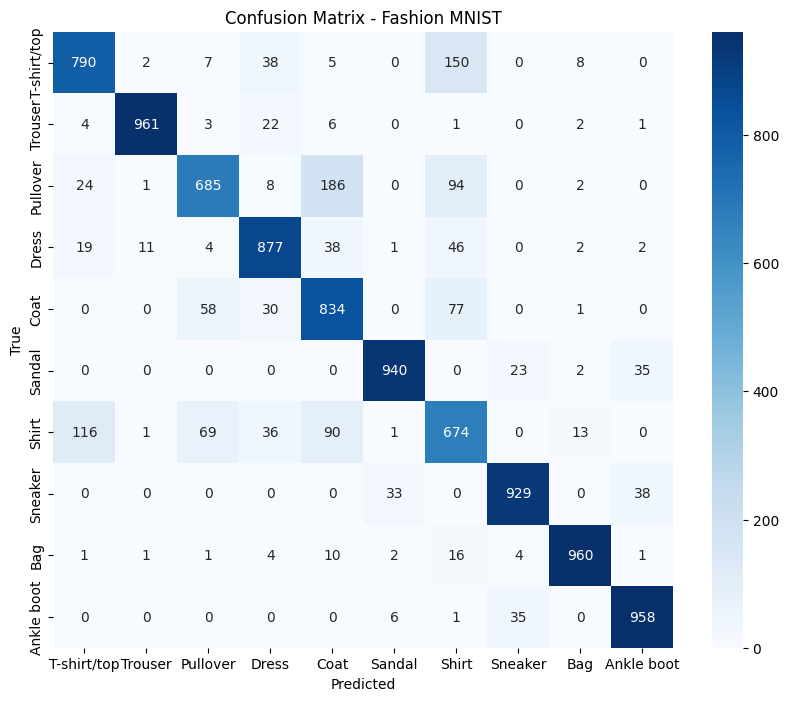

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Fashion MNIST')
plt.show()
# roc curve, auc curve